In [42]:
import os

# 1. See what is actually inside your input directory
input_contents = os.listdir("/kaggle/input/")
print("Available data folders:", input_contents)

# 2. Dynamically use the first folder name found
if input_contents:
    detected_dataset = input_contents[0]
    full_path = os.path.join("/kaggle/input", detected_dataset)
    print("\nTrying to read inside:", full_path)
    print("Contents:", os.listdir(full_path))
else:
    print("\n[ERROR] No datasets found! Please click '+ Add Data' in the right sidebar.")


Available data folders: ['datasets']

Trying to read inside: /kaggle/input/datasets
Contents: ['assemelqirsh']


In [43]:

# Your actual identified Kaggle path
dataset_path = "/kaggle/input/datasets/assemelqirsh"

# Loop through and see the underlying directories (e.g., train, test, chest_xray)
for dirname, _, filenames in os.walk(dataset_path):
    # Print directory if it contains files
    if len(filenames) > 0:
        print(f"Directory: {dirname}")
        print(f"Sample Files: {filenames[:3]}\n")


Directory: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA
Sample Files: ['person1230_virus_2081.jpeg', 'person466_virus_960.jpeg', 'person114_virus_217.jpeg']

Directory: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/NORMAL
Sample Files: ['NORMAL2-IM-0336-0001.jpeg', 'NORMAL2-IM-1294-0001-0002.jpeg', 'IM-0421-0001.jpeg']

Directory: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test/PNEUMONIA
Sample Files: ['person746_virus_1369.jpeg', 'person399_bacteria_1805.jpeg', 'person622_bacteria_2494.jpeg']

Directory: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test/NORMAL
Sample Files: ['IM-0713-0001.jpeg', 'NORMAL2-IM-0428-0001.jpeg', 'IM-0103-0001.jpeg']

Directory: /kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/train/PNEUMONIA
Sample Files: ['person1180_virus_2010.jpeg', 'person1676_virus_2892.jpeg', 'person1513_virus_2632.jpeg']

Directory: /kaggle/input/datasets/asse

In [44]:
print(os.listdir("/kaggle/input/"))

['datasets']


In [45]:
for dirname, _, filenames in os.walk("/kaggle/input/datasets/assemelqirsh"):
    print(dirname)

/kaggle/input/datasets/assemelqirsh
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/val/NORMAL
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/test/NORMAL
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/train
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/train/PNEUMONIA
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray/train/NORMAL
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray_bicubic
/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray_

In [46]:
DATA_DIR = "/kaggle/input/datasets/assemelqirsh/chest-x-ray-dataset/chest_xray"

print(os.listdir(DATA_DIR))

['val', 'test', 'train']


In [47]:
for split in ["train", "test", "val"]:
    path = os.path.join(DATA_DIR, split)
    
    print("\n", split.upper())
    print(os.listdir(path))


 TRAIN
['PNEUMONIA', 'NORMAL']

 TEST
['PNEUMONIA', 'NORMAL']

 VAL
['PNEUMONIA', 'NORMAL']


In [48]:
for split in ["train", "test", "val"]:
    
    print("\n", split.upper())
    
    for label in ["NORMAL", "PNEUMONIA"]:
        path = os.path.join(DATA_DIR, split, label)
        
        images = [
            f for f in os.listdir(path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ]
        
        print(label, ":", len(images))


 TRAIN
NORMAL : 1266
PNEUMONIA : 3418

 TEST
NORMAL : 159
PNEUMONIA : 428

 VAL
NORMAL : 158
PNEUMONIA : 427


In [49]:
import matplotlib.pyplot as plt
from PIL import Image
import random

In [50]:
train_path = os.path.join(DATA_DIR, "train")

normal_path = os.path.join(train_path, "NORMAL")
pneumonia_path = os.path.join(train_path, "PNEUMONIA")

print("Normal images:", len(os.listdir(normal_path)))
print("Pneumonia images:", len(os.listdir(pneumonia_path)))

Normal images: 1266
Pneumonia images: 3418


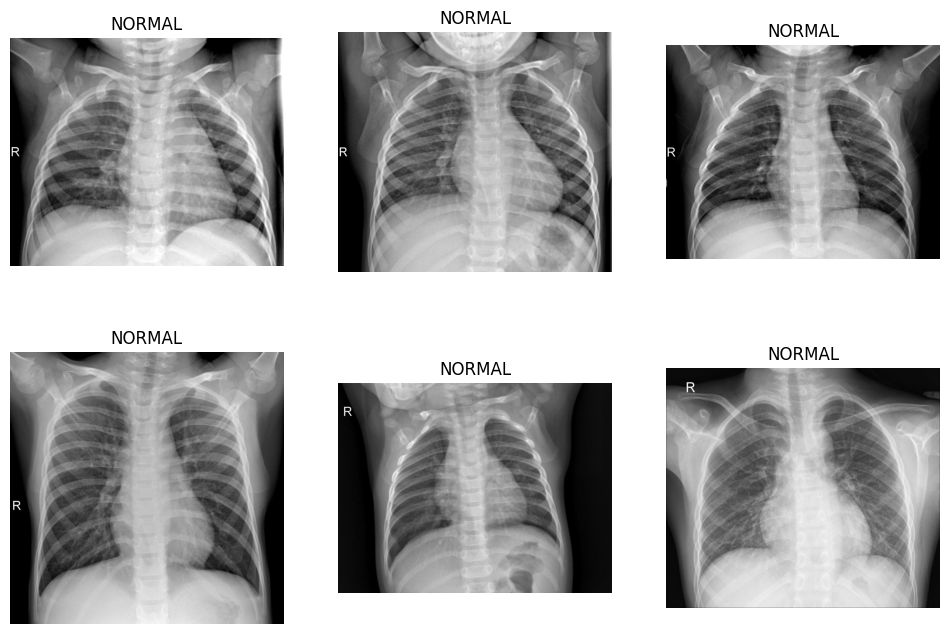

In [51]:
plt.figure(figsize = (12,8))
images = random.sample(os.listdir(normal_path),6)
for i,img_name in enumerate(images):
    img = Image.open(os.path.join(normal_path,img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap = 'gray')
    plt.title('NORMAL')
    plt.axis('off')
plt.show()

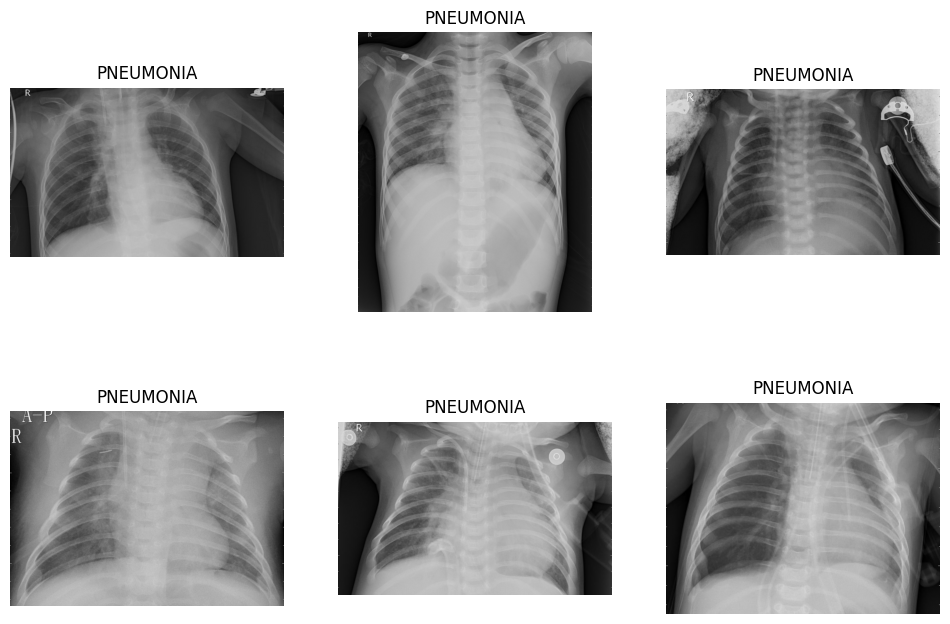

In [52]:
plt.figure(figsize=(12,8))
images = random.sample(os.listdir(pneumonia_path),6)

for i,img_name in enumerate(images):
    img = Image.open(os.path.join(pneumonia_path,img_name))

    plt.subplot(2,3,i+1)
    plt.imshow(img,cmap='gray')
    plt.title("PNEUMONIA")
    plt.axis('off')
plt.show()

In [53]:
sample_image = os.listdir(normal_path)[0]

img = Image.open(
    os.path.join(normal_path,sample_image)
)

print("Image size:", img.size)
print("Image mode:", img.mode)

'''L = grayscale image
    1 channel'''

Image size: (1336, 1128)
Image mode: L


'L = grayscale image\n    1 channel'

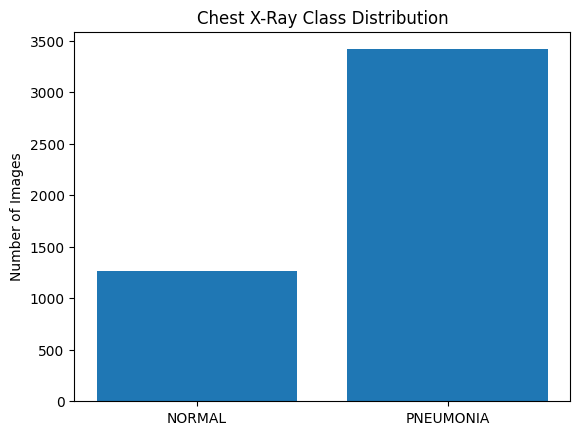

In [54]:
classes = ["NORMAL","PNEUMONIA"]

counts = [
    len(os.listdir(normal_path)),
    len(os.listdir(pneumonia_path))
]


plt.bar(classes,counts)

plt.title("Chest X-Ray Class Distribution")
plt.ylabel("Number of Images")

plt.show()

In [55]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout,BatchNormalization,RandomZoom,RandomRotation,RandomFlip,RandomContrast,GlobalAveragePooling2D
from tensorflow.keras.activations import relu,sigmoid
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

In [56]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR,"train"),
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    color_mode = 'grayscale',
    label_mode = 'binary',
    shuffle=True
)

Found 4684 files belonging to 2 classes.


In [57]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR,"val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary"
)

Found 585 files belonging to 2 classes.


In [58]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR,"test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="binary",
    shuffle=False
)

Found 587 files belonging to 2 classes.


In [59]:
print(train_ds.class_names)

['NORMAL', 'PNEUMONIA']


In [60]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x,y: (normalization_layer(x),y)
)

val_ds = val_ds.map(
    lambda x,y: (normalization_layer(x),y)
)

test_ds = test_ds.map(
    lambda x,y: (normalization_layer(x),y)
)

In [61]:
AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [62]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 1)
Label shape: (32, 1)


In [63]:
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape = (224,224,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128,activation = 'relu'),
    Dropout(0.5),

    Dense(1,activation = 'sigmoid')
    
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,409 (42.61 MB)

 Trainable params: 11,168,961 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [64]:
history = model.fit(train_ds,validation_data = val_ds,epochs = 15)

Epoch 1/15


2026-08-08 05:56:02.638031: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 05:56:02.787519: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/147 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.4219 - loss: 16.4770

I0000 00:00:1786168566.375249     144 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8295 - loss: 3.3173

2026-08-08 05:56:17.384837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-08 05:56:17.528872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


147/147 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - accuracy: 0.8762 - loss: 1.0841 - val_accuracy: 0.7299 - val_loss: 52.4471
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8952 - loss: 0.2727 - val_accuracy: 0.7299 - val_loss: 34.3967
Epoch 3/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9148 - loss: 0.2000 - val_accuracy: 0.7350 - val_loss: 10.0727
Epoch 4/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9142 - loss: 0.2478 - val_accuracy: 0.8051 - val_loss: 1.2650
Epoch 5/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9101 - loss: 0.1811 - val_accuracy: 0.9487 - val_loss: 0.1460
Epoch 6/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9142 - loss: 0.1726 - val_accuracy: 0.8718 - val_loss: 0.3649
Epoch 7/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.9184 - loss: 0.1548 - val_accuracy: 0.9179 - val_loss: 0.2134
Epoch 8/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9383 - loss: 0.1272 - val_acc

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(
    ["Train","Validation"]
)

plt.show()

In [75]:
model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9574 - loss: 0.1347


[0.13467389345169067, 0.9574105739593506]

In [67]:
model.evaluate(val_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9453 - loss: 0.1621


[0.16206803917884827, 0.9452991485595703]

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step


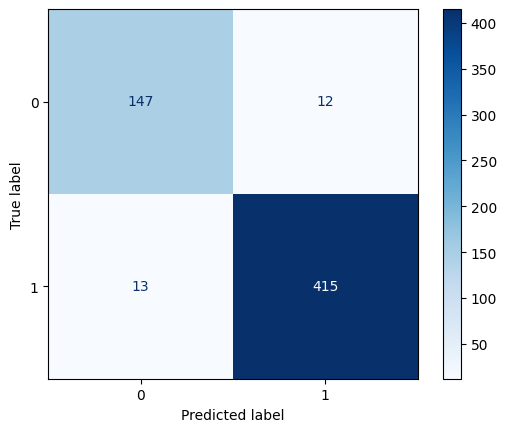

In [68]:
predictions = model.predict(test_ds)
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)
actual_labels = []

for images, labels in test_ds:
    actual_labels.extend(labels.numpy())


actual_labels = np.array(actual_labels).reshape(-1)
cm = confusion_matrix(
    actual_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap = "Blues")
plt.show()


In [69]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=["NORMAL","PNEUMONIA"]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.92      0.92      0.92       159
   PNEUMONIA       0.97      0.97      0.97       428

    accuracy                           0.96       587
   macro avg       0.95      0.95      0.95       587
weighted avg       0.96      0.96      0.96       587



In [70]:
data_augmentation = Sequential([
    RandomFlip('horizontal'),
    RandomZoom(0.10),
    RandomContrast(0.10),
    RandomRotation(0.5)
])

In [71]:
dg_model = Sequential([
    tf.keras.Input(shape =(224,224,1)),
    data_augmentation,
    Conv2D(32,(3,3),padding = 'same',activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),padding = 'same',activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),padding = 'same',activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(256,(3,3),padding = 'same',activation = 'relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),

    Dense(128,activation = 'relu'),
    Dropout(0.5),

    Dense(1,activation = 'sigmoid')
                 ])

dg_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy',
              tf.keras.metrics.Precision(name="precision"),
              tf.keras.metrics.Recall(name="recall")
              ]
)

dg_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [72]:
import numpy as np
normal_count = 0
pneumonia_count = 0

for _, labels in train_ds:
    labels = labels.numpy().reshape(-1)

    normal_count += np.sum(labels == 0)
    pneumonia_count += np.sum(labels == 1)

total = normal_count + pneumonia_count

class_weight = {
    0: total / (2 * normal_count),
    1: total / (2 * pneumonia_count)
}

print(class_weight)

{0: np.float64(1.8499210110584519), 1: np.float64(0.6851960210649503)}


In [73]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [76]:
dg_history = dg_model.fit(train_ds,epochs = 20,class_weight = class_weight,validation_data = val_ds,callbacks =[early_stop,reduce_lr])

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.8627 - loss: 0.3253 - precision: 0.9627 - recall: 0.8446 - val_accuracy: 0.7299 - val_loss: 2.9083 - val_precision: 0.7299 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 140ms/step - accuracy: 0.8768 - loss: 0.3092 - precision: 0.9647 - recall: 0.8628 - val_accuracy: 0.7299 - val_loss: 1.6612 - val_precision: 0.7299 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/step - accuracy: 0.8725 - loss: 0.3045 - precision: 0.9620 - recall: 0.8593 - val_accuracy: 0.7385 - val_loss: 0.8355 - val_precision: 0.7420 - val_recall: 0.9836 - learning_rate: 0.0010
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.8892 - loss: 0.2766 - precision: 0.9662 - recall: 0.8789 - val_accuracy: 0.2803 - val_loss: 8.1014 - val_precision: 1.0000 - val_recall: 0.0141 - learning_rate: 0.0010
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 20s 136ms/st

In [77]:
test_results = model.evaluate(test_ds)

print("Test results:")
for name, value in zip(model.metrics_names, test_results):
    print(name, ":", value)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.9574 - loss: 0.1347
Test results:
loss : 0.13467389345169067
compile_metrics : 0.9574105739593506


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


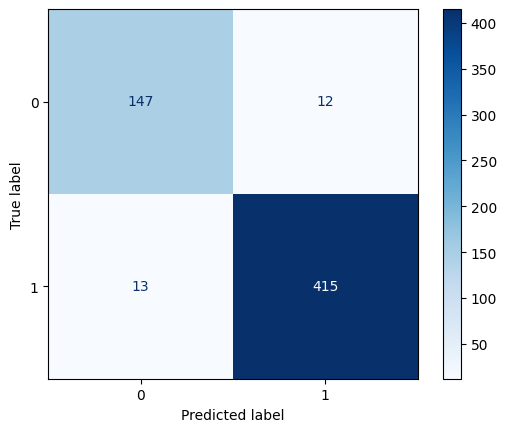

In [79]:
predictions = model.predict(test_ds)

predicted_labels = (
    predictions >= 0.5
).astype(int).reshape(-1)

actual_labels = []

for images, labels in test_ds:
    actual_labels.extend(
        labels.numpy().reshape(-1)
    )

actual_labels = np.array(actual_labels)

cm = confusion_matrix(
    actual_labels,
    predicted_labels
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')
plt.show()

In [80]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=[
            "NORMAL",
            "PNEUMONIA"
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.92      0.92      0.92       159
   PNEUMONIA       0.97      0.97      0.97       428

    accuracy                           0.96       587
   macro avg       0.95      0.95      0.95       587
weighted avg       0.96      0.96      0.96       587

